# 04. 이상치 탐지
비정상적인 이용 패턴(이상 트립, 이상 대여소 시간대)을 탐지합니다.

## 분석 전략

따릉이 운영에서 발생하는 이상 상황을 **3가지 운영 문제**로 정의하고, 각각에 최적화된 방법을 적용한다.

| # | 운영 문제 | 탐지 방법 | 이유 |
|---|---|---|---|
| 1 | **데이터 품질 이상** (GPS 오류) | Rule-based | 물리적으로 불가능한 속도 → 명확한 기준 적용 |
| 2 | **방치 자전거** | Rule-based + IF 보완 | 룰로 명확한 케이스 탐지, IF는 룰이 못 잡는 경계 케이스 보완 |
| 3 | **수요·공급 불균형** | STL (시계열) + 유출 분석 | 일별·시간대별 패턴에서 벗어난 이상 수요 탐지 |

> **핵심 원칙**: Isolation Forest는 "모든 이상치"를 찾는 도구가 아니라, **방치 의심 트립** (단거리 + 장시간) 영역에서 룰이 놓친 케이스를 발굴하는 보완재로 사용한다. 장거리 이용은 통계적으로 희귀하지만 운영적으로는 정상이므로 IF 적용 전 제외한다.

In [1]:
import sys, gc, joblib
sys.path.insert(0, '..')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from pathlib import Path

for font_path in ["/System/Library/Fonts/Supplemental/AppleGothic.ttf", "/Library/Fonts/NanumGothic.ttf"]:
    import pathlib
    if pathlib.Path(font_path).exists():
        fm.fontManager.addfont(font_path)
        prop = fm.FontProperties(fname=font_path)
        plt.rcParams["font.family"] = prop.get_name()
        break
plt.rcParams["axes.unicode_minus"] = False

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import LocalOutlierFactor

from src.data_loader import load_processed, save_processed
from src.feature_engineering import build_trip_features
from src.evaluation import plot_anomaly_timeline
print("\u2705 준비 완료")

✅ 준비 완료


## 1. 데이터 로드 및 약지도 이상치 정의

In [2]:
df = load_processed("rentals_clean")
df = build_trip_features(df)

# 약지도(rule-based) 이상치 레이블 정의 (평가용)
conditions = (
    (df["speed_kmh"] > 35) |                               # 너무 빠른 속도
    ((df["use_m"] > 500) & (df["use_min"] < 1)) |          # 짧은 시간 + 긴 거리
    (df["use_min"] > 360) |                                # 6시간 초과
    ((df["use_m"] == 0) & (df["use_min"] > 30))            # 거리 없는데 30분 초과
)
df["weak_label"] = conditions.astype(int)
print(f"약지도 이상치 수: {df['weak_label'].sum():,}  ({df['weak_label'].mean()*100:.2f}%)")

# 통계 요약
print("\n이상치 vs 정상 비교:")
print(df.groupby("weak_label")[["use_min", "use_m", "speed_kmh"]].mean().round(2))

📂 Loaded rentals_clean.parquet → shape: (8559939, 27)


약지도 이상치 수: 23,024  (0.27%)

이상치 vs 정상 비교:
            use_min    use_m  speed_kmh
weak_label                             
0             19.75  2158.72       8.36
1             75.88  1141.04       8.58


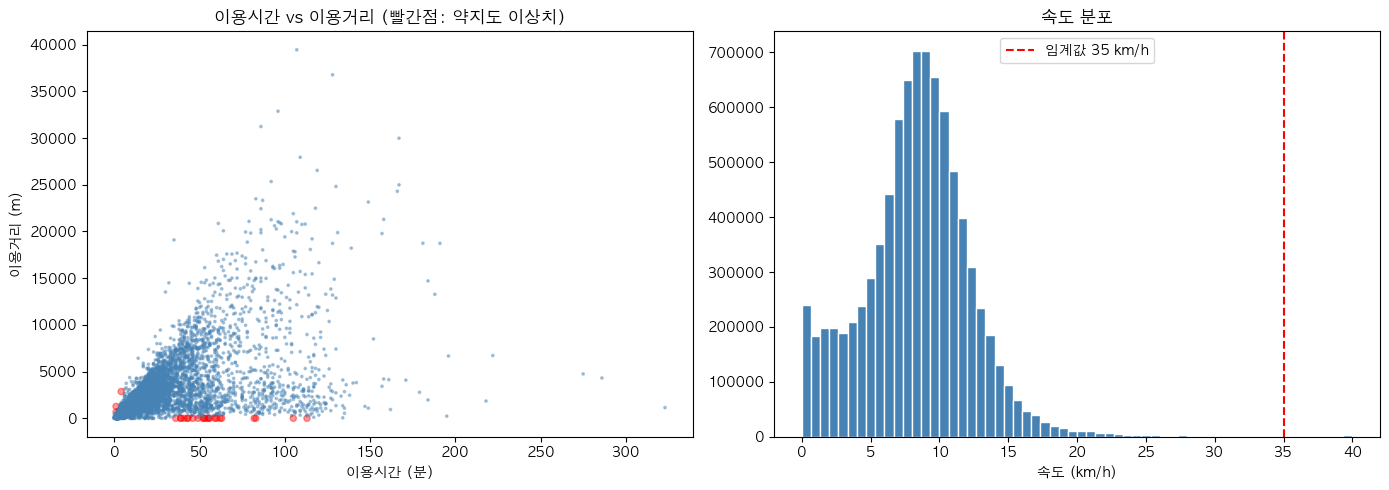

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 이용시간 vs 이용거리 산점도
sample = df.sample(min(10000, len(df)), random_state=42)
colors = ["steelblue" if l == 0 else "red" for l in sample["weak_label"]]
sizes  = [3 if l == 0 else 20 for l in sample["weak_label"]]
axes[0].scatter(sample["use_min"], sample["use_m"], c=colors, s=sizes, alpha=0.4)
axes[0].set_title("이용시간 vs 이용거리 (빨간점: 약지도 이상치)")
axes[0].set_xlabel("이용시간 (분)")
axes[0].set_ylabel("이용거리 (m)")

# 속도 분포
axes[1].hist(df["speed_kmh"].dropna(), bins=60, color="steelblue", edgecolor="white")
axes[1].axvline(35, color="red", linestyle="--", label="임계값 35 km/h")
axes[1].set_title("속도 분포")
axes[1].set_xlabel("속도 (km/h)")
axes[1].legend()

plt.tight_layout()
plt.savefig("../reports/figures/anomaly_overview.png", dpi=150)
plt.show()

## 2. Isolation Forest — 방치 의심 트립 탐지 (단거리·장시간 영역)

**목적**: 룰 기준(use_min_calc > 360 & use_m < 500)이 명확하게 잡지 못하는 **경계 케이스** 탐지.

**적용 전 필터**:
- GPS 오류 의심 제외 (`speed_kmh > 35`)
- 장거리 이용 제외 (`use_m > 3000`) — 통계적으로 희귀하지만 운영적으로 정상
- IF는 단거리·장시간 영역에만 집중

**contamination**: 실제 방치율 0.003%를 고려해 `0.005`로 설정 (기존 0.02 → 6배 하향)

In [4]:
# ── 방치 의심 영역으로 범위 제한 ──────────────────────────────────────────────
# 장거리(use_m > 3000) 및 GPS 오류(speed_kmh > 35)는 운영 정상 또는 데이터 품질 문제이므로 제외
# IF는 단거리·장시간 조합에서 룰이 놓친 경계 케이스를 찾는 역할
df_if_scope = df[
    (df["use_m"] <= 3000) &
    (df["speed_kmh"] <= 35)
].copy()

FEAT_COLS = ["use_min_calc", "use_m", "speed_kmh", "hour", "dow"]
df_iso = df_if_scope[FEAT_COLS + ["weak_label"]].dropna()

sample_n = min(200_000, len(df_iso))
df_sample = df_iso.sample(n=sample_n, random_state=42)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_sample[FEAT_COLS])

# contamination=0.005: 실제 방치율(0.003%)에 근접하도록 기존 0.02에서 하향
iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.005,
    random_state=42,
    n_jobs=-1,
)
iso_forest.fit(X_scaled)

df_sample = df_sample.copy()
df_sample["iso_score"] = -iso_forest.score_samples(X_scaled)  # 높을수록 이상
df_sample["iso_label"] = (iso_forest.predict(X_scaled) == -1).astype(int)

n_detected = df_sample["iso_label"].sum()
print(f"적용 범위: 단거리(≤3km) + 정상속도(≤35km/h) 트립 {len(df_if_scope):,}건")
print(f"샘플 크기: {sample_n:,}건")
print(f"Isolation Forest 탐지 이상치: {n_detected:,}건 ({n_detected/sample_n*100:.2f}%)")

# 탐지된 케이스의 주요 지표 확인
print("\n탐지 건 vs 정상 건 비교:")
print(df_sample.groupby("iso_label")[["use_min_calc", "use_m", "speed_kmh"]].mean().round(1))

# 약지도 레이블과 비교
from sklearn.metrics import classification_report as sk_cr
print("\n약지도 레이블 대비 평가 (단거리 영역 한정):")
print(sk_cr(df_sample["weak_label"], df_sample["iso_label"], target_names=["정상", "이상치"]))

적용 범위: 단거리(≤3km) + 정상속도(≤35km/h) 트립 6,930,404건
샘플 크기: 200,000건
Isolation Forest 탐지 이상치: 1,000건 (0.50%)

탐지 건 vs 정상 건 비교:
           use_min_calc   use_m  speed_kmh
iso_label                                 
0                  14.0  1211.0        8.2
1                 153.0  1408.5        1.4

약지도 레이블 대비 평가 (단거리 영역 한정):
              precision    recall  f1-score   support

          정상       1.00      1.00      1.00    199499
         이상치       0.11      0.22      0.15       501

    accuracy                           0.99    200000
   macro avg       0.55      0.61      0.57    200000
weighted avg       1.00      0.99      0.99    200000



In [5]:
# LOF (작은 샘플에서만)
lof_n = min(20_000, len(df_sample))
df_lof = df_sample.head(lof_n).copy()
X_lof = scaler.transform(df_lof[FEAT_COLS])

lof = LocalOutlierFactor(n_neighbors=20, contamination=0.02, n_jobs=-1)
lof_labels = (lof.fit_predict(X_lof) == -1).astype(int)

df_lof["lof_label"] = lof_labels
df_lof["lof_score"] = -lof.negative_outlier_factor_

print(f"LOF 탐지 이상치: {lof_labels.sum():,}개")
print("\nLOF 약지도 레이블 대비 평가:")
print(sk_cr(df_lof["weak_label"], df_lof["lof_label"], target_names=["정상", "이상치"]))

LOF 탐지 이상치: 400개

LOF 약지도 레이블 대비 평가:
              precision    recall  f1-score   support

          정상       1.00      0.98      0.99     19951
         이상치       0.03      0.22      0.05        49

    accuracy                           0.98     20000
   macro avg       0.51      0.60      0.52     20000
weighted avg       1.00      0.98      0.99     20000



## 3. 방치 건 심층 분석 (Isolation Forest 탐지 건 기준)

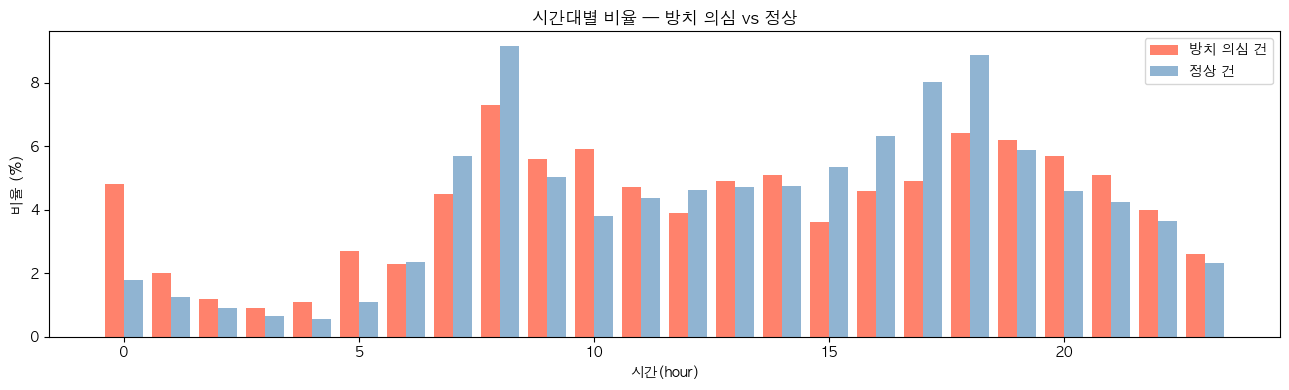

방치 건 중 18~23시 비율: 30.0%
정상 건 중 18~23시 비율: 29.6%


In [6]:
abandon = df_sample[df_sample["iso_label"] == 1].copy()
normal  = df_sample[df_sample["iso_label"] == 0].copy()

# ── 1. 시간대별 분포 ──────────────────────────────────────────────────────────
hour_abandon = abandon["hour"].value_counts().sort_index()
hour_normal  = normal["hour"].value_counts().sort_index()
hour_ratio   = (hour_abandon / hour_abandon.sum() * 100).reindex(range(24), fill_value=0)
hour_normal_r= (hour_normal  / hour_normal.sum()  * 100).reindex(range(24), fill_value=0)

fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(hour_ratio.index - 0.2, hour_ratio.values,  width=0.4, label="방치 의심 건", color="tomato",    alpha=0.8)
ax.bar(hour_ratio.index + 0.2, hour_normal_r.values, width=0.4, label="정상 건",     color="steelblue", alpha=0.6)
ax.set_title("시간대별 비율 — 방치 의심 vs 정상")
ax.set_xlabel("시간(hour)")
ax.set_ylabel("비율 (%)")
ax.legend()
plt.tight_layout()
plt.savefig("../reports/figures/abandon_hour_dist.png", dpi=150)
plt.show()

# 야간(18~23시) 집중 여부
night_pct = hour_ratio[18:24].sum()
print(f"방치 건 중 18~23시 비율: {night_pct:.1f}%")
print(f"정상 건 중 18~23시 비율: {hour_normal_r[18:24].sum():.1f}%")

=== 이동거리 비교 ===
방치 의심 건 — 중앙값: 1408m  평균: 1409m
정상 건     — 중앙값: 1072m  평균: 1211m


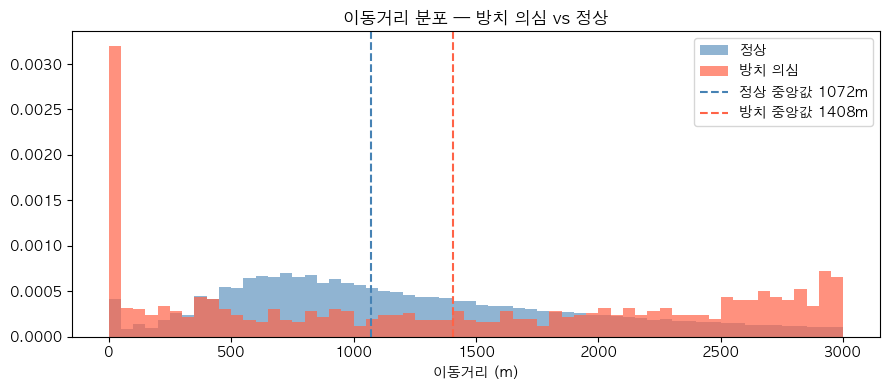

In [7]:
# ── 2. 이동거리 중앙값 실측 ───────────────────────────────────────────────────
med_abandon = abandon["use_m"].median()
med_normal  = normal["use_m"].median()
avg_abandon = abandon["use_m"].mean()
avg_normal  = normal["use_m"].mean()

print("=== 이동거리 비교 ===")
print(f"방치 의심 건 — 중앙값: {med_abandon:.0f}m  평균: {avg_abandon:.0f}m")
print(f"정상 건     — 중앙값: {med_normal:.0f}m  평균: {avg_normal:.0f}m")

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(normal["use_m"].clip(0, 10000),  bins=60, alpha=0.6, color="steelblue", label="정상", density=True)
ax.hist(abandon["use_m"].clip(0, 10000), bins=60, alpha=0.7, color="tomato",    label="방치 의심", density=True)
ax.axvline(med_normal,  color="steelblue", linestyle="--", linewidth=1.5, label=f"정상 중앙값 {med_normal:.0f}m")
ax.axvline(med_abandon, color="tomato",    linestyle="--", linewidth=1.5, label=f"방치 중앙값 {med_abandon:.0f}m")
ax.set_title("이동거리 분포 — 방치 의심 vs 정상")
ax.set_xlabel("이동거리 (m)")
ax.legend()
plt.tight_layout()
plt.savefig("../reports/figures/abandon_dist_hist.png", dpi=150)
plt.show()

              방치_건수   전체_건수  방치_비율(%)
user_segment                         
비정기 (30회 미만)    442   89673      0.49
정기 (30회+)       558  110327      0.51


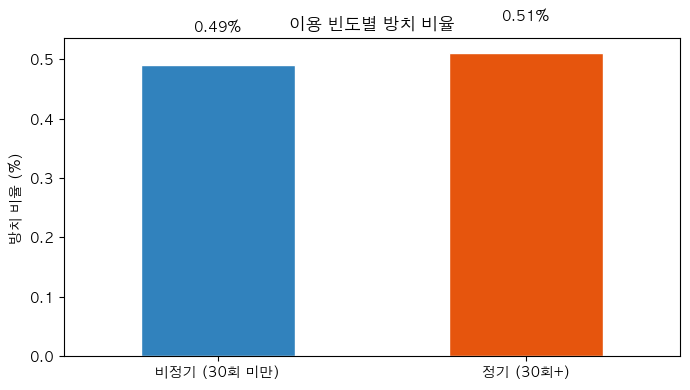

In [8]:
# ── 3. 이용 빈도별(정기/비정기) 방치 비율 ────────────────────────────────────
# user_id 없음 → (birth_year, gender) 조합을 유저 proxy로 사용
df_full = df.copy()

# df_sample의 인덱스는 df_full의 인덱스와 대응
df_sample_full = df_full.loc[df_sample.index, ["birth_year", "gender"]].copy()
df_sample_full["iso_label"] = df_sample["iso_label"].values

# 유저별 이용 횟수 (전체 df 기준)
user_freq = df_full.groupby(["birth_year", "gender"]).size().reset_index(name="total_rides")
df_sample_full = df_sample_full.merge(user_freq, on=["birth_year", "gender"], how="left")

# 정기(>= 30회) / 비정기(< 30회)
df_sample_full["user_segment"] = df_sample_full["total_rides"].apply(
    lambda x: "정기 (30회+)" if x >= 30 else "비정기 (30회 미만)"
)

seg_stats = df_sample_full.groupby("user_segment")["iso_label"].agg(
    방치_건수="sum", 전체_건수="count"
)
seg_stats["방치_비율(%)"] = (seg_stats["방치_건수"] / seg_stats["전체_건수"] * 100).round(2)
print(seg_stats)

fig, ax = plt.subplots(figsize=(7, 4))
colors = ["#3182bd", "#e6550d"]
seg_stats["방치_비율(%)"].plot(kind="bar", ax=ax, color=colors, edgecolor="white", width=0.5)
ax.set_title("이용 빈도별 방치 비율")
ax.set_ylabel("방치 비율 (%)")
ax.set_xlabel("")
plt.xticks(rotation=0)
for p in ax.patches:
    ax.text(p.get_x() + p.get_width()/2, p.get_height() + 0.05,
            f"{p.get_height():.2f}%", ha="center", va="bottom")
plt.tight_layout()
plt.savefig("../reports/figures/abandon_user_freq.png", dpi=150)
plt.show()

## 4. Isolation Forest 탐지 건 세부 분류

탐지된 이상치를 패턴별로 분류합니다.
- **방치형**: use_min > 120분 AND use_m < 500m
- **속도이상형**: speed_kmh > 30 (GPS 오류 의심)
- **장거리형**: use_m > 10,000m
- **기타**: 위에 해당 없는 이상치

=== Isolation Forest 탐지 건 유형 분류 ===
  기타        :   863건 (86.3%)
  방치형       :   134건 (13.4%)
  속도이상형     :     3건 (0.3%)

=== 유형별 평균 프로파일 ===
              use_min_calc   use_m  speed_kmh
anomaly_type                                 
기타                   150.8  1596.9        1.5
방치형                  169.0   167.9        0.2
속도이상형                 74.4  2628.3       31.5


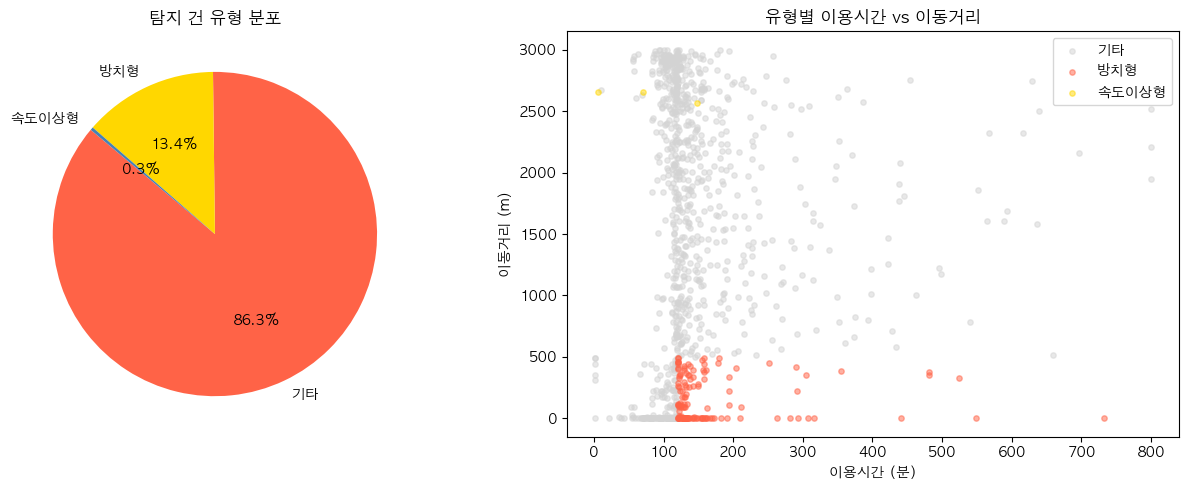

In [9]:
def classify_anomaly(row):
    if row["use_min_calc"] > 120 and row["use_m"] < 500:
        return "방치형"
    elif row["speed_kmh"] > 30:
        return "속도이상형"
    elif row["use_m"] > 10000:
        return "장거리형"
    else:
        return "기타"

abandon["anomaly_type"] = abandon.apply(classify_anomaly, axis=1)

type_counts = abandon["anomaly_type"].value_counts()
type_pct    = (type_counts / len(abandon) * 100).round(1)

print("=== Isolation Forest 탐지 건 유형 분류 ===")
for t, n, p in zip(type_counts.index, type_counts.values, type_pct.values):
    print(f"  {t:<10}: {n:>5}건 ({p}%)")

print("\n=== 유형별 평균 프로파일 ===")
print(abandon.groupby("anomaly_type")[["use_min_calc", "use_m", "speed_kmh"]].mean().round(1))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors = ["tomato", "gold", "steelblue", "lightgray"]
axes[0].pie(type_counts.values, labels=type_counts.index, autopct="%1.1f%%",
            colors=colors, startangle=140)
axes[0].set_title("탐지 건 유형 분포")

palette = {"방치형": "tomato", "속도이상형": "gold", "장거리형": "steelblue", "기타": "lightgray"}
for atype, grp in abandon.groupby("anomaly_type"):
    axes[1].scatter(grp["use_min_calc"].clip(0, 800), grp["use_m"].clip(0, 50000),
                    label=atype, alpha=0.5, s=15, color=palette[atype])
axes[1].set_xlabel("이용시간 (분)")
axes[1].set_ylabel("이동거리 (m)")
axes[1].set_title("유형별 이용시간 vs 이동거리")
axes[1].legend()

plt.tight_layout()
plt.savefig("../reports/figures/anomaly_type_breakdown.png", dpi=150)
plt.show()

## 5. 방치 정의 재설정 (룰 기반)

`use_min > 360분 AND use_m < 500m` 조건으로 방치를 직접 정의하고 특성을 분석합니다.

룰 기반 방치 건: 68건 (0.00%)

=== 방치 건 기초 통계 ===
       use_min  use_m  hour   dow
count     68.0   68.0  68.0  68.0
mean     448.7  240.8   8.2   3.5
std       39.1  186.8   5.5   2.0
min      362.0    0.0   0.0   0.0
25%      412.8   10.0   3.0   2.0
50%      480.0  266.6   9.0   4.0
75%      480.0  411.3  13.0   5.0
max      480.0  493.4  19.0   6.0


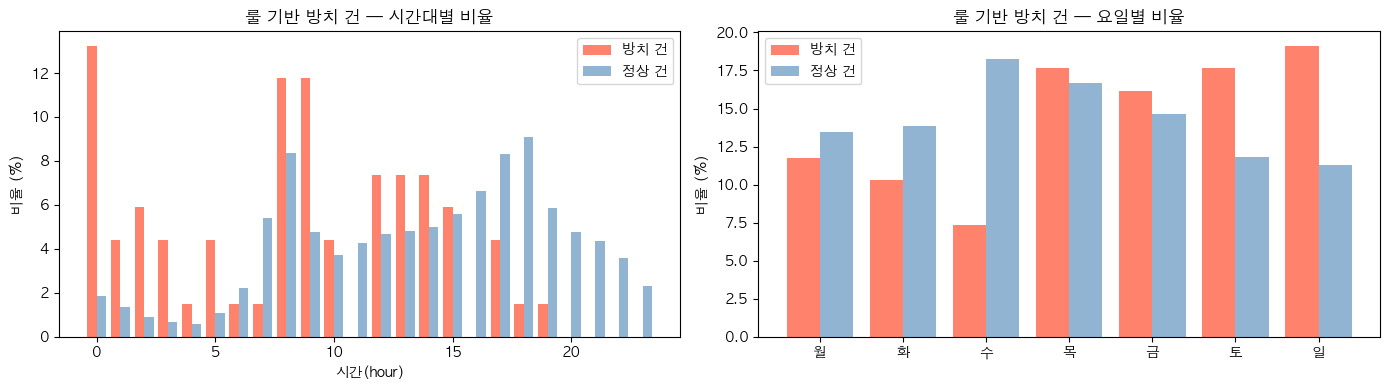


방치 건 18~23시 비율: 2.9%
정상 건 18~23시 비율: 29.9%


In [10]:
df_full2 = df.copy()
rule_abandon = df_full2[(df_full2["use_min"] > 360) & (df_full2["use_m"] < 500)].copy()
rule_normal  = df_full2[~((df_full2["use_min"] > 360) & (df_full2["use_m"] < 500))].copy()

n_abandon = len(rule_abandon)
n_total   = len(df_full2)
print(f"룰 기반 방치 건: {n_abandon:,}건 ({n_abandon/n_total*100:.2f}%)")
print(f"\n=== 방치 건 기초 통계 ===")
print(rule_abandon[["use_min", "use_m", "hour", "dow"]].describe().round(1))

# 시간대별 분포
hr_ab  = (rule_abandon["hour"].value_counts().sort_index() / n_abandon * 100).reindex(range(24), fill_value=0)
hr_nm  = (rule_normal["hour"].value_counts().sort_index()  / len(rule_normal) * 100).reindex(range(24), fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(hr_ab.index - 0.2, hr_ab.values, width=0.4, color="tomato",    alpha=0.8, label="방치 건")
axes[0].bar(hr_ab.index + 0.2, hr_nm.values, width=0.4, color="steelblue", alpha=0.6, label="정상 건")
axes[0].set_title("룰 기반 방치 건 — 시간대별 비율")
axes[0].set_xlabel("시간(hour)")
axes[0].set_ylabel("비율 (%)")
axes[0].legend()

# 요일별 분포
dow_labels = ["월", "화", "수", "목", "금", "토", "일"]
dow_ab = (rule_abandon["dow"].value_counts().sort_index() / n_abandon * 100).reindex(range(7), fill_value=0)
dow_nm = (rule_normal["dow"].value_counts().sort_index()  / len(rule_normal) * 100).reindex(range(7), fill_value=0)
x = range(7)
axes[1].bar([i - 0.2 for i in x], dow_ab.values, width=0.4, color="tomato",    alpha=0.8, label="방치 건")
axes[1].bar([i + 0.2 for i in x], dow_nm.values, width=0.4, color="steelblue", alpha=0.6, label="정상 건")
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(dow_labels)
axes[1].set_title("룰 기반 방치 건 — 요일별 비율")
axes[1].set_ylabel("비율 (%)")
axes[1].legend()

plt.tight_layout()
plt.savefig("../reports/figures/rule_abandon_dist.png", dpi=150)
plt.show()

night_pct2 = hr_ab[18:24].sum()
print(f"\n방치 건 18~23시 비율: {night_pct2:.1f}%")
print(f"정상 건 18~23시 비율: {hr_nm[18:24].sum():.1f}%")

## 6. Isolation Forest가 장거리 건을 이상치로 잡은 이유 분석

속도·시간·거리 조합 시각화로 IF가 무엇을 기준으로 이상치를 판별했는지 확인합니다.

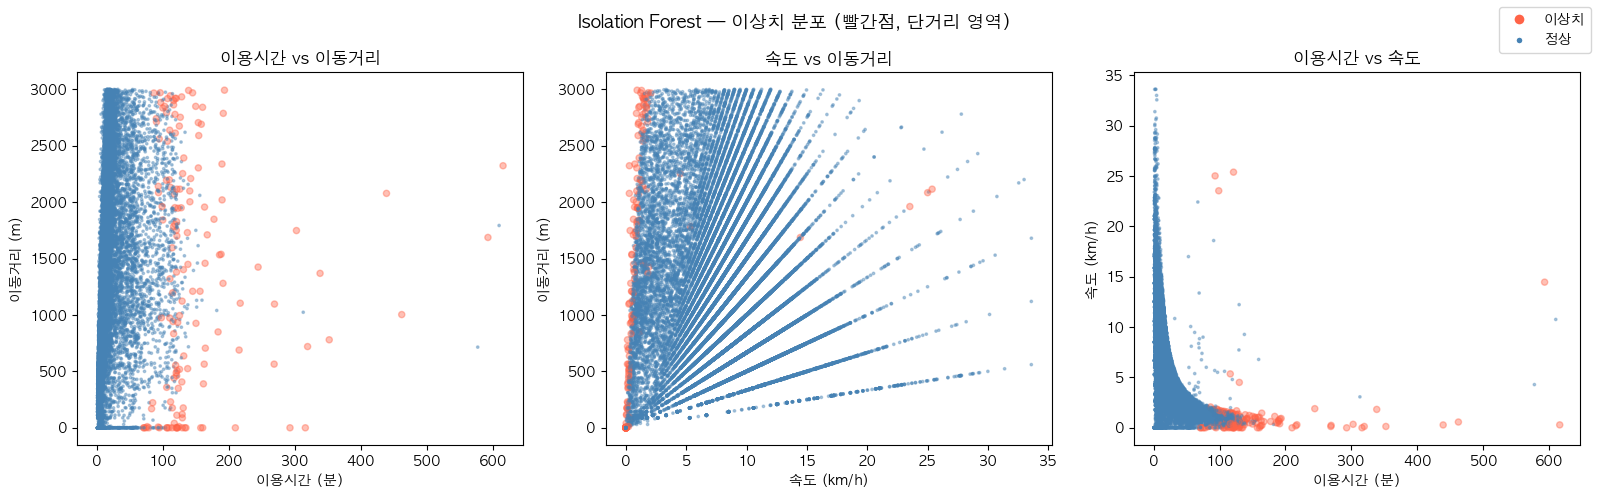

=== 이상치 구간별 분포 ===
time_bucket
~30분          9
30~120분     413
120~360분    535
360분+        43
Name: count, dtype: int64

이동거리 분포:
dist_bucket2
~500m      178
500~2km    324
2~10km     373
10km+        0
Name: count, dtype: int64


In [11]:
sample_plot = df_sample.sample(min(30000, len(df_sample)), random_state=42)
colors_plot  = sample_plot["iso_label"].map({0: "steelblue", 1: "tomato"})
sizes_plot   = sample_plot["iso_label"].map({0: 3, 1: 20})

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].scatter(sample_plot["use_min_calc"].clip(0, 800), sample_plot["use_m"].clip(0, 30000),
                c=colors_plot, s=sizes_plot, alpha=0.4)
axes[0].set_xlabel("이용시간 (분)")
axes[0].set_ylabel("이동거리 (m)")
axes[0].set_title("이용시간 vs 이동거리")

axes[1].scatter(sample_plot["speed_kmh"].clip(0, 40), sample_plot["use_m"].clip(0, 30000),
                c=colors_plot, s=sizes_plot, alpha=0.4)
axes[1].set_xlabel("속도 (km/h)")
axes[1].set_ylabel("이동거리 (m)")
axes[1].set_title("속도 vs 이동거리")

axes[2].scatter(sample_plot["use_min_calc"].clip(0, 800), sample_plot["speed_kmh"].clip(0, 40),
                c=colors_plot, s=sizes_plot, alpha=0.4)
axes[2].set_xlabel("이용시간 (분)")
axes[2].set_ylabel("속도 (km/h)")
axes[2].set_title("이용시간 vs 속도")

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='tomato',    markersize=8, label='이상치'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='steelblue', markersize=5, label='정상'),
]
fig.legend(handles=legend_elements, loc="upper right")
plt.suptitle("Isolation Forest — 이상치 분포 (빨간점, 단거리 영역)", fontsize=13)
plt.tight_layout()
plt.savefig("../reports/figures/if_scatter_analysis.png", dpi=150)
plt.show()

print("=== 이상치 구간별 분포 ===")
bins_time = [0, 30, 120, 360, 9999]
labels_t  = ["~30분", "30~120분", "120~360분", "360분+"]
abandon["time_bucket"] = pd.cut(abandon["use_min_calc"], bins=bins_time, labels=labels_t)
print(abandon["time_bucket"].value_counts().sort_index())

bins_dist = [0, 500, 2000, 10000, 999999]
labels_d  = ["~500m", "500~2km", "2~10km", "10km+"]
abandon["dist_bucket2"] = pd.cut(abandon["use_m"], bins=bins_dist, labels=labels_d)
print("\n이동거리 분포:")
print(abandon["dist_bucket2"].value_counts().sort_index())

## 7. 480분 Cap 이슈 — use_min_calc로 방치 재탐색

`use_min`은 최대 480분으로 cap되어 있어 실제 장시간 방치 건이 걸러졌을 가능성이 있습니다.
원본 계산값 `use_min_calc`를 사용해 다시 탐색합니다.

use_min(cap) 기반 방치 건   : 68건
use_min_calc(원본) 기반 방치: 248건  (0.003%)

use_min == 480 건수(cap 적용):  841건
use_min_calc > 480 건수(원본):  1,333건

=== 실제 방치 건 기초 통계 (use_min_calc 기준) ===
       use_min_calc  use_m   hour    dow
count         248.0  248.0  248.0  248.0
mean          527.4  164.0    8.5    3.1
std           169.0  188.4    5.4    1.9
min           360.6    0.0    0.0    0.0
25%           402.1    0.0    5.0    2.0
50%           489.9    6.5    8.0    3.0
75%           594.5  352.2   12.2    5.0
max          1520.5  499.9   19.0    6.0


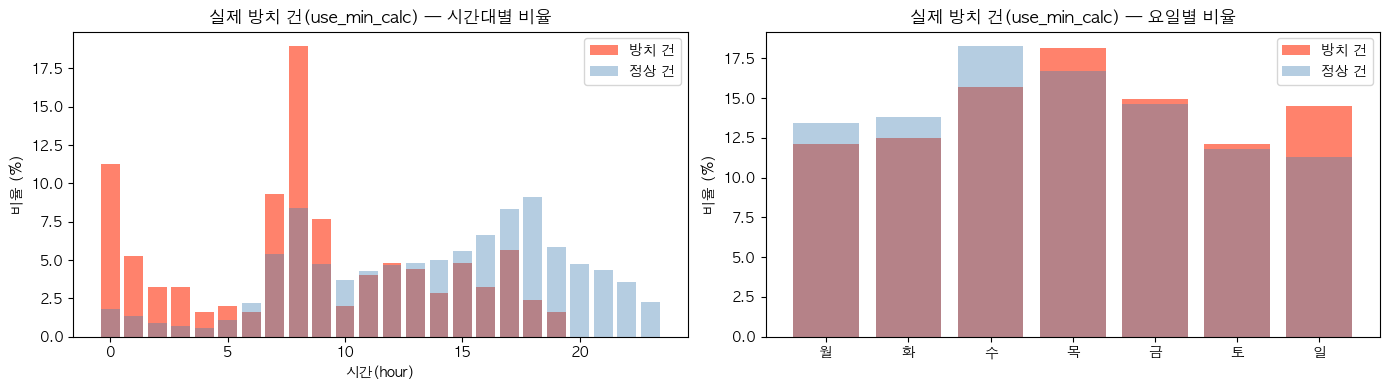


방치 건 18~23시 비율: 4.0%
정상 건 18~23시 비율: 29.9%

방치 건 주말 비율: 26.6%
정상 건 주말 비율: 23.1%


In [12]:
# use_min_calc 기반 방치 탐색 (cap 제거)
true_abandon = df_full2[(df_full2["use_min_calc"] > 360) & (df_full2["use_m"] < 500)].copy()
n_true = len(true_abandon)
print(f"use_min(cap) 기반 방치 건   : {len(rule_abandon):,}건")
print(f"use_min_calc(원본) 기반 방치: {n_true:,}건  ({n_true/len(df_full2)*100:.3f}%)")
print(f"\nuse_min == 480 건수(cap 적용):  {(df_full2['use_min'] == 480).sum():,}건")
print(f"use_min_calc > 480 건수(원본):  {(df_full2['use_min_calc'] > 480).sum():,}건")

print(f"\n=== 실제 방치 건 기초 통계 (use_min_calc 기준) ===")
print(true_abandon[["use_min_calc", "use_m", "hour", "dow"]].describe().round(1))

# 시간대 / 요일 분포
hr_true  = (true_abandon["hour"].value_counts().sort_index() / n_true * 100).reindex(range(24), fill_value=0)
dow_true = (true_abandon["dow"].value_counts().sort_index()  / n_true * 100).reindex(range(7), fill_value=0)
dow_labels = ["월", "화", "수", "목", "금", "토", "일"]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(hr_true.index, hr_true.values, color="tomato", alpha=0.8)
axes[0].bar(hr_nm.index, hr_nm.values, color="steelblue", alpha=0.4, label="정상 건")
axes[0].set_title("실제 방치 건(use_min_calc) — 시간대별 비율")
axes[0].set_xlabel("시간(hour)")
axes[0].set_ylabel("비율 (%)")
axes[0].legend(["방치 건", "정상 건"])

axes[1].bar(range(7), dow_true.values, color="tomato", alpha=0.8, label="방치 건")
axes[1].bar(range(7), dow_nm.values,   color="steelblue", alpha=0.4, label="정상 건")
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(dow_labels)
axes[1].set_title("실제 방치 건(use_min_calc) — 요일별 비율")
axes[1].set_ylabel("비율 (%)")
axes[1].legend()

plt.tight_layout()
plt.savefig("../reports/figures/true_abandon_dist.png", dpi=150)
plt.show()

night_true = hr_true[18:24].sum()
print(f"\n방치 건 18~23시 비율: {night_true:.1f}%")
print(f"정상 건 18~23시 비율: {hr_nm[18:24].sum():.1f}%")
print(f"\n방치 건 주말 비율: {dow_true[5:].sum():.1f}%")
print(f"정상 건 주말 비율: {dow_nm[5:].sum():.1f}%")

### 방치 발생 스테이션 분석 — 어디서 가장 많이 발생하나?

방치 자전거가 집중되는 스테이션을 파악해 **현장 순찰 우선순위**를 도출한다.

=== 방치 자전거 발생 Top10 스테이션 ===
             방치 건수  전체 대여  방치율(%)
rent_stn_id                      
ST-1837        8.0   4893   0.163
ST-662         3.0   4883   0.061
ST-406         3.0   1585   0.189
ST-1892        3.0   1465   0.205
ST-1364        2.0   4186   0.048
ST-1275        2.0   8666   0.023
ST-1668        2.0   5331   0.038
ST-1681        2.0  17700   0.011
ST-255         2.0   6140   0.033
ST-2557        2.0  13629   0.015


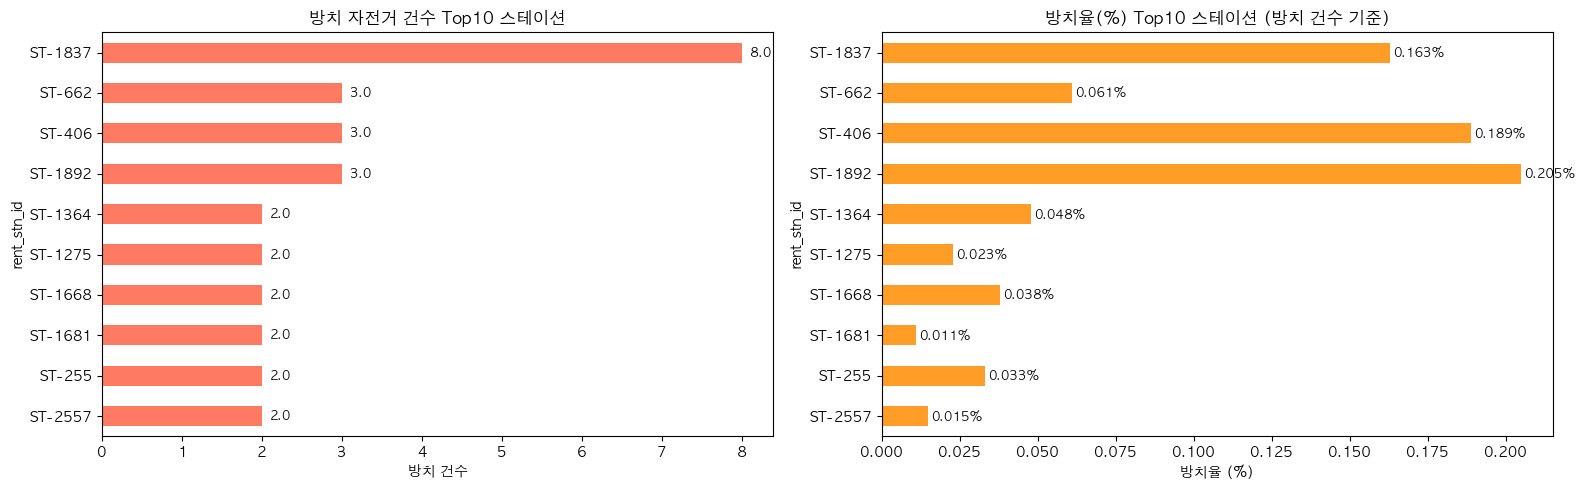


→ 방치 건수 1위 스테이션: ST-1837
  방치 8.0건 / 전체 4893건 (0.163%)


In [13]:
# ── 방치 발생 스테이션 Top10 ──────────────────────────────────────────────────
# true_abandon: use_min_calc > 360 & use_m < 500 (직전 셀에서 정의됨)

# 대여 스테이션 기준 (방치 시작 위치)
abandon_by_stn = true_abandon.groupby("rent_stn_id").size().sort_values(ascending=False)
total_by_stn   = df.groupby("rent_stn_id").size()

# 방치율 = 방치 건수 / 해당 스테이션 전체 대여 건수
abandon_rate = (abandon_by_stn / total_by_stn * 100).dropna()

top_stn_df = pd.DataFrame({
    "방치 건수": abandon_by_stn,
    "전체 대여": total_by_stn,
    "방치율(%)": abandon_rate.round(3),
}).dropna().sort_values("방치 건수", ascending=False).head(10)

print("=== 방치 자전거 발생 Top10 스테이션 ===")
print(top_stn_df.to_string())

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 왼쪽: 방치 건수 Top10
top_stn_df["방치 건수"].plot(kind="barh", ax=axes[0], color="tomato", alpha=0.85)
axes[0].invert_yaxis()
axes[0].set_title("방치 자전거 건수 Top10 스테이션")
axes[0].set_xlabel("방치 건수")
for i, v in enumerate(top_stn_df["방치 건수"]):
    axes[0].text(v + 0.1, i, str(v), va="center", fontsize=9)

# 오른쪽: 방치율 Top10 (건수 기준 동일 스테이션)
top_stn_df["방치율(%)"].plot(kind="barh", ax=axes[1], color="darkorange", alpha=0.85)
axes[1].invert_yaxis()
axes[1].set_title("방치율(%) Top10 스테이션 (방치 건수 기준)")
axes[1].set_xlabel("방치율 (%)")
for i, v in enumerate(top_stn_df["방치율(%)"]):
    axes[1].text(v + 0.001, i, f"{v:.3f}%", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("../reports/figures/abandon_stn_top10.png", dpi=150)
plt.show()

print(f"\n→ 방치 건수 1위 스테이션: {top_stn_df.index[0]}")
print(f"  방치 {top_stn_df['방치 건수'].iloc[0]}건 / 전체 {top_stn_df['전체 대여'].iloc[0]:.0f}건 ({top_stn_df['방치율(%)'].iloc[0]:.3f}%)")

## 8. 장거리 이상 건 분석 — GPS 오류 vs 실제 장거리

10km+ 건의 속도 분포를 기준으로 GPS 오류 의심 건과 실제 장거리 이용 건을 구분합니다.

10km+ 전체: 202,658건
  GPS 오류 의심 (속도 30km/h+) : 315건 (0.2%)
  실제 장거리 (속도 ~30km/h)   : 202,343건 (99.8%)

=== 실제 장거리 건 속도 구간 분포 ===
speed_calc
0~5        2794
5~10      61565
10~15    109154
15~20     25597
20~30      3233
Name: count, dtype: int64

=== 실제 장거리 건 시간대 분포 (상위 5) ===
hour
17    10.1
18     9.6
16     9.0
15     8.3
14     7.5
Name: count, dtype: float64

=== 실제 장거리 건 이용시간 분포 ===
count    202343.0
mean         80.6
std          38.6
min          21.1
25%          56.9
50%          73.7
75%          96.5
max        1488.8
Name: use_min_calc, dtype: float64


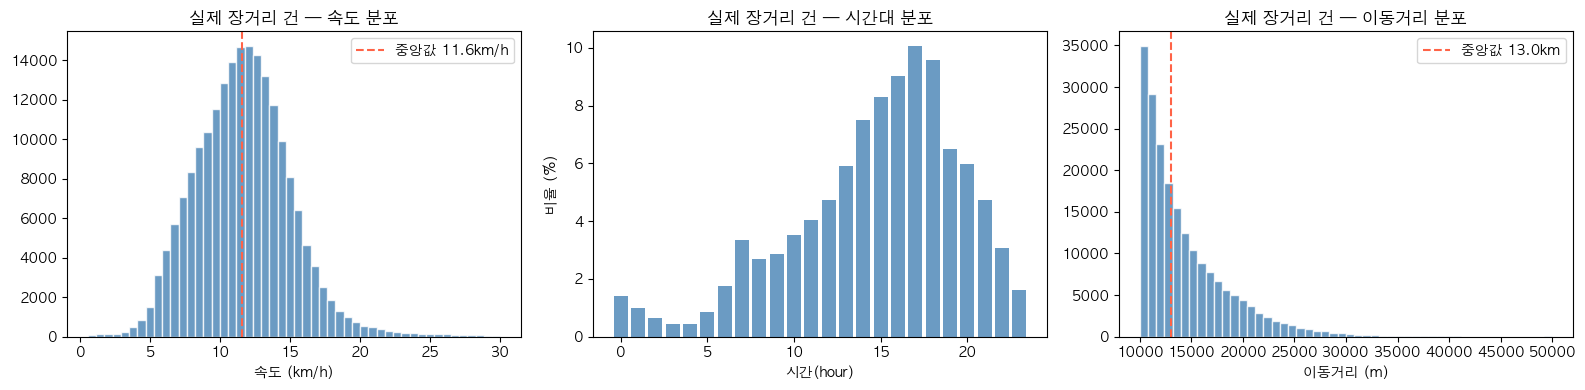

In [14]:
long_dist_df = df_full2[df_full2["use_m"] > 10000].copy()
long_dist_df["speed_calc"] = (
    (long_dist_df["use_m"] / 1000) / (long_dist_df["use_min_calc"] / 60)
).clip(0, 100)

# 구분: 속도 30km/h+ → GPS 오류 의심 / 나머지 → 실제 장거리
gps_error   = long_dist_df[long_dist_df["speed_calc"] > 30]
real_long   = long_dist_df[long_dist_df["speed_calc"] <= 30]

print(f"10km+ 전체: {len(long_dist_df):,}건")
print(f"  GPS 오류 의심 (속도 30km/h+) : {len(gps_error):,}건 ({len(gps_error)/len(long_dist_df)*100:.1f}%)")
print(f"  실제 장거리 (속도 ~30km/h)   : {len(real_long):,}건 ({len(real_long)/len(long_dist_df)*100:.1f}%)")

print(f"\n=== 실제 장거리 건 속도 구간 분포 ===")
speed_bins = pd.cut(real_long["speed_calc"], bins=[0,5,10,15,20,30], labels=["0~5","5~10","10~15","15~20","20~30"])
print(speed_bins.value_counts().sort_index())

print(f"\n=== 실제 장거리 건 시간대 분포 (상위 5) ===")
print((real_long["hour"].value_counts().sort_values(ascending=False) / len(real_long) * 100).head(5).round(1))

print(f"\n=== 실제 장거리 건 이용시간 분포 ===")
print(real_long["use_min_calc"].describe().round(1))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 속도 분포
axes[0].hist(real_long["speed_calc"], bins=50, color="steelblue", edgecolor="white", alpha=0.8)
axes[0].axvline(real_long["speed_calc"].median(), color="tomato", linestyle="--",
                label=f"중앙값 {real_long['speed_calc'].median():.1f}km/h")
axes[0].set_title("실제 장거리 건 — 속도 분포")
axes[0].set_xlabel("속도 (km/h)")
axes[0].legend()

# 시간대 분포
hr_long = (real_long["hour"].value_counts().sort_index() / len(real_long) * 100).reindex(range(24), fill_value=0)
axes[1].bar(hr_long.index, hr_long.values, color="steelblue", alpha=0.8)
axes[1].set_title("실제 장거리 건 — 시간대 분포")
axes[1].set_xlabel("시간(hour)")
axes[1].set_ylabel("비율 (%)")

# 이동거리 분포
axes[2].hist(real_long["use_m"].clip(0, 50000), bins=50, color="steelblue", edgecolor="white", alpha=0.8)
axes[2].axvline(real_long["use_m"].median(), color="tomato", linestyle="--",
                label=f"중앙값 {real_long['use_m'].median()/1000:.1f}km")
axes[2].set_title("실제 장거리 건 — 이동거리 분포")
axes[2].set_xlabel("이동거리 (m)")
axes[2].legend()

plt.tight_layout()
plt.savefig("../reports/figures/long_dist_analysis.png", dpi=150)
plt.show()

## 9. [비즈니스 인사이트 A] STL 수요 이상 → 주요 스테이션 전체 이상 히트맵 + 운영 캘린더

**기존**: 최대 스테이션 1개에만 STL 적용
**개선**: 대여량 기준 상위 50개 스테이션 전체에 STL 적용 → **스테이션×날짜 이상 히트맵**으로 패턴 시각화

- 스테이션별 이상 시간대 집계 → 이상이 집중되는 날짜/스테이션 파악
- 기존 패턴 분류 로직(공휴일·주말·평일 급증/급감) 동일하게 적용

📂 Loaded station_hourly_demand.parquet → shape: (3835657, 5)


분석 스테이션: 50개
전체 STL 이상 시간대: 2776개

=== 패턴별 분류 ===
pattern
주말                      1275
기타 급증                    522
평일 저녁 급증 (레저/이벤트)        499
기타 급감                    344
공휴일                      116
평일 출근 급감 (한파/악천후 추정)      20
Name: count, dtype: int64

=== 급증 vs 급감 ===
direction
급증    1476
급감    1300
Name: count, dtype: int64


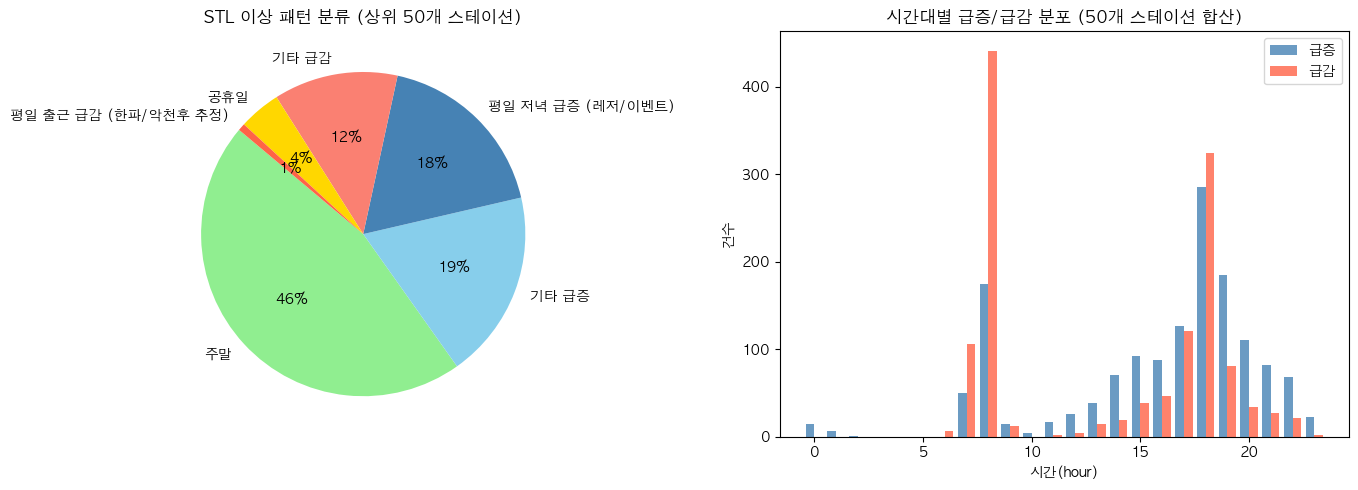

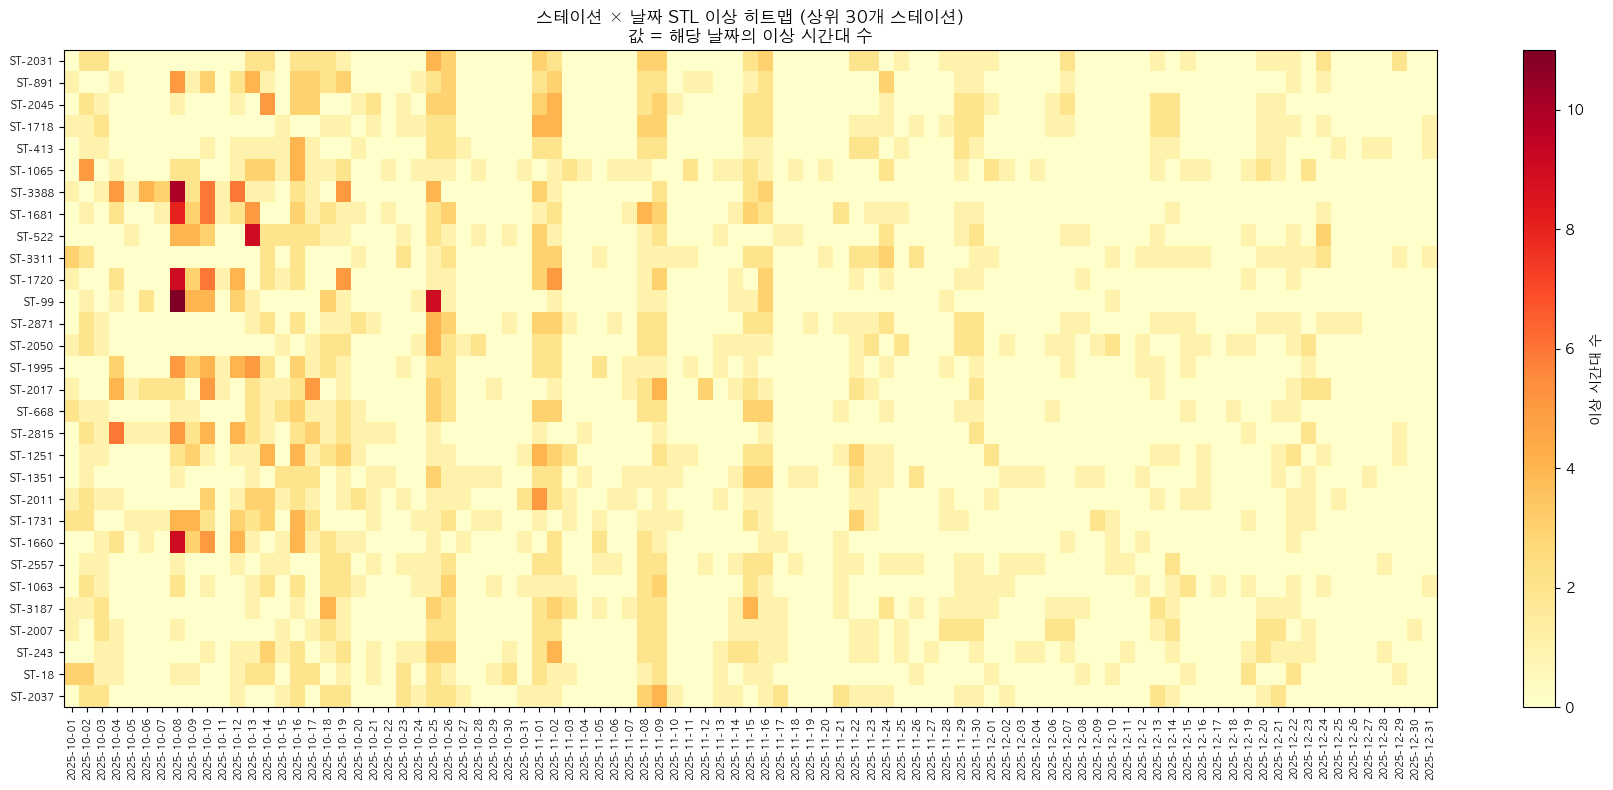


=== 운영 룰 도출 ===
- 평일 08시 급감 이벤트: 441건 → 해당일 출근 대여소 재배치 불필요
- 평일 17~19시 급증 이벤트: 597건 → 퇴근 대여소 사전 재고 확충 필요

- 이상 집중 날짜 Top5:
date
2025-10-08    154
2025-10-16    113
2025-10-25    105
2025-11-01     97
2025-11-09     96

- 이상 발생 Top10 스테이션:
stn_id
ST-1681    69
ST-3402    69
ST-3388    65
ST-1065    64
ST-2017    62
ST-3403    62
ST-1720    61
ST-1251    61
ST-1938    61
ST-522     60


In [15]:
from statsmodels.tsa.seasonal import STL
import warnings

hourly = load_processed("station_hourly_demand")

# ── 상위 50개 스테이션 선택 ──────────────────────────────────────────────────
top50_stns = (
    hourly.groupby("stn_id")["rent_count"].sum()
    .nlargest(50).index.tolist()
)

HOLIDAYS_SET = set(pd.to_datetime(["2025-10-03", "2025-10-09", "2025-12-25"]))

def classify_stl(row):
    dt   = row["datetime"]
    date = dt.normalize()
    hour = dt.hour
    dow  = dt.dayofweek
    if date in HOLIDAYS_SET:
        return "공휴일"
    if dow >= 5:
        return "주말"
    if hour == 8 and row["resid"] < 0:
        return "평일 출근 급감 (한파/악천후 추정)"
    if 17 <= hour <= 19 and row["resid"] > 0:
        return "평일 저녁 급증 (레저/이벤트)"
    if row["resid"] < 0:
        return "기타 급감"
    return "기타 급증"

# ── 50개 스테이션 STL 루프 ────────────────────────────────────────────────────
all_stl_records = []

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for stn_id in top50_stns:
        stn_ts = (
            hourly[hourly["stn_id"] == stn_id]
            .set_index("datetime_hour")["rent_count"]
            .asfreq("h").fillna(0)
        )
        if len(stn_ts) < 48:
            continue
        result   = STL(stn_ts, period=24, robust=True).fit()
        resid_std = result.resid.std()
        if resid_std == 0:
            continue
        mask = np.abs(result.resid) > 3 * resid_std
        for dt, resid_val in result.resid[mask].items():
            all_stl_records.append({
                "stn_id": stn_id,
                "datetime": dt,
                "resid": resid_val,
            })

stl_all = pd.DataFrame(all_stl_records)
stl_all["pattern"]   = stl_all.apply(classify_stl, axis=1)
stl_all["direction"] = stl_all["resid"].apply(lambda x: "급증" if x > 0 else "급감")
stl_all["date"]      = stl_all["datetime"].dt.date
stl_all["hour"]      = stl_all["datetime"].dt.hour

print(f"분석 스테이션: {len(top50_stns)}개")
print(f"전체 STL 이상 시간대: {len(stl_all)}개\n")
print("=== 패턴별 분류 ===")
print(stl_all["pattern"].value_counts())
print("\n=== 급증 vs 급감 ===")
print(stl_all["direction"].value_counts())

# ── 시각화 1: 패턴 파이 + 시간대별 분포 ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

palette = {"공휴일": "gold", "주말": "lightgreen",
           "평일 출근 급감 (한파/악천후 추정)": "tomato",
           "평일 저녁 급증 (레저/이벤트)": "steelblue",
           "기타 급감": "salmon", "기타 급증": "skyblue"}
pattern_counts = stl_all["pattern"].value_counts()
colors_pie = [palette.get(p, "gray") for p in pattern_counts.index]
axes[0].pie(pattern_counts.values, labels=pattern_counts.index, autopct="%1.0f%%",
            colors=colors_pie, startangle=140)
axes[0].set_title(f"STL 이상 패턴 분류 (상위 50개 스테이션)")

hour_dir = stl_all.groupby("hour")["direction"].value_counts().unstack(fill_value=0)
if "급증" not in hour_dir.columns: hour_dir["급증"] = 0
if "급감" not in hour_dir.columns: hour_dir["급감"] = 0
axes[1].bar(hour_dir.index - 0.2, hour_dir["급증"], width=0.4, color="steelblue", alpha=0.8, label="급증")
axes[1].bar(hour_dir.index + 0.2, hour_dir["급감"], width=0.4, color="tomato",    alpha=0.8, label="급감")
axes[1].set_title("시간대별 급증/급감 분포 (50개 스테이션 합산)")
axes[1].set_xlabel("시간(hour)")
axes[1].set_ylabel("건수")
axes[1].legend()

plt.tight_layout()
plt.savefig("../reports/figures/stl_pattern_calendar.png", dpi=150)
plt.show()

# ── 시각화 2: 스테이션 × 날짜 이상 히트맵 ───────────────────────────────────
pivot = (
    stl_all.groupby(["stn_id", "date"]).size()
    .unstack(fill_value=0)
)

# 상위 30개 스테이션만 (가독성)
top30_for_heatmap = (
    hourly.groupby("stn_id")["rent_count"].sum()
    .nlargest(30).index
)
pivot_plot = pivot.reindex(top30_for_heatmap).fillna(0)

fig, ax = plt.subplots(figsize=(18, 8))
im = ax.imshow(pivot_plot.values, aspect="auto", cmap="YlOrRd", interpolation="nearest")
ax.set_yticks(range(len(pivot_plot)))
ax.set_yticklabels(pivot_plot.index, fontsize=7)
date_labels = [str(d) for d in pivot_plot.columns]
ax.set_xticks(range(len(date_labels)))
ax.set_xticklabels(date_labels, rotation=90, fontsize=7)
ax.set_title("스테이션 × 날짜 STL 이상 히트맵 (상위 30개 스테이션)\n값 = 해당 날짜의 이상 시간대 수")
plt.colorbar(im, ax=ax, label="이상 시간대 수")
plt.tight_layout()
plt.savefig("../reports/figures/stl_station_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

# ── 운영 룰 ──────────────────────────────────────────────────────────────────
commute_drop  = stl_all[(stl_all["hour"] == 8)  & (stl_all["direction"] == "급감")]
evening_surge = stl_all[(stl_all["hour"].between(17, 19)) & (stl_all["direction"] == "급증")]
print("\n=== 운영 룰 도출 ===")
print(f"- 평일 08시 급감 이벤트: {len(commute_drop)}건 → 해당일 출근 대여소 재배치 불필요")
print(f"- 평일 17~19시 급증 이벤트: {len(evening_surge)}건 → 퇴근 대여소 사전 재고 확충 필요")

# 이상이 가장 많이 집중된 날짜 Top5
top_dates = stl_all["date"].value_counts().head(5)
print(f"\n- 이상 집중 날짜 Top5:\n{top_dates.to_string()}")

# 스테이션 기준 이상 발생 Top10
top_stns_anomaly = stl_all["stn_id"].value_counts().head(10)
print(f"\n- 이상 발생 Top10 스테이션:\n{top_stns_anomaly.to_string()}")

## 10. [비즈니스 인사이트 B] 장거리 이용 → 대여소별 자전거 유출 경로 분석

10km+ 장거리 이용 건의 출발 대여소 → 도착 대여소를 추적하여, 어떤 대여소가 장거리 이용으로 자전거를 "잃는지" 분석합니다. 순유출이 큰 대여소는 재배치 트럭이 우선 방문해야 합니다.

장거리 이용(10km+) 관련 대여소 수: 2,771개

=== 자전거 순유출 TOP 10 (재배치 트럭 우선 방문 대상) ===
             rent_stn_name  출발_건수  도착_건수  순유출
ST-891   롯데월드타워(잠실역2번출구 쪽)    430    184  246
ST-66             NH농협은행 앞    398    217  181
ST-55           유진투자증권빌딩 앞    507    340  167
ST-797        포스코사거리(기업은행)    223     60  163
ST-914            상계역 3번출구    362    206  156
ST-366            옥수역 3번출구    900    758  142
ST-3397             한국산업은행    172     35  137
ST-3105        보라매병원역 1번출구    328    193  135
ST-3143           서울대벤처타운역    637    506  131
ST-1547           서울대학교 정문    199     71  128

=== 자전거 순유입 TOP 10 (자전거 공급원 후보) ===
              rent_stn_name  출발_건수  도착_건수  순유출
ST-3388         한강버스 망원 선착장   1953   2512 -559
ST-99    자양(뚝섬한강공원)역 1번출구 앞    817   1261 -444
ST-376           청계천 생태교실 앞   1462   1904 -442
ST-426                당산육갑문   1321   1718 -397
ST-1195            응봉역 1번출구    898   1242 -344
ST-3390         한강버스 뚝섬 선착장   1420   1701 -281
ST-3391         한강버스 잠실 선착장   1226   1494 -268
ST-442  

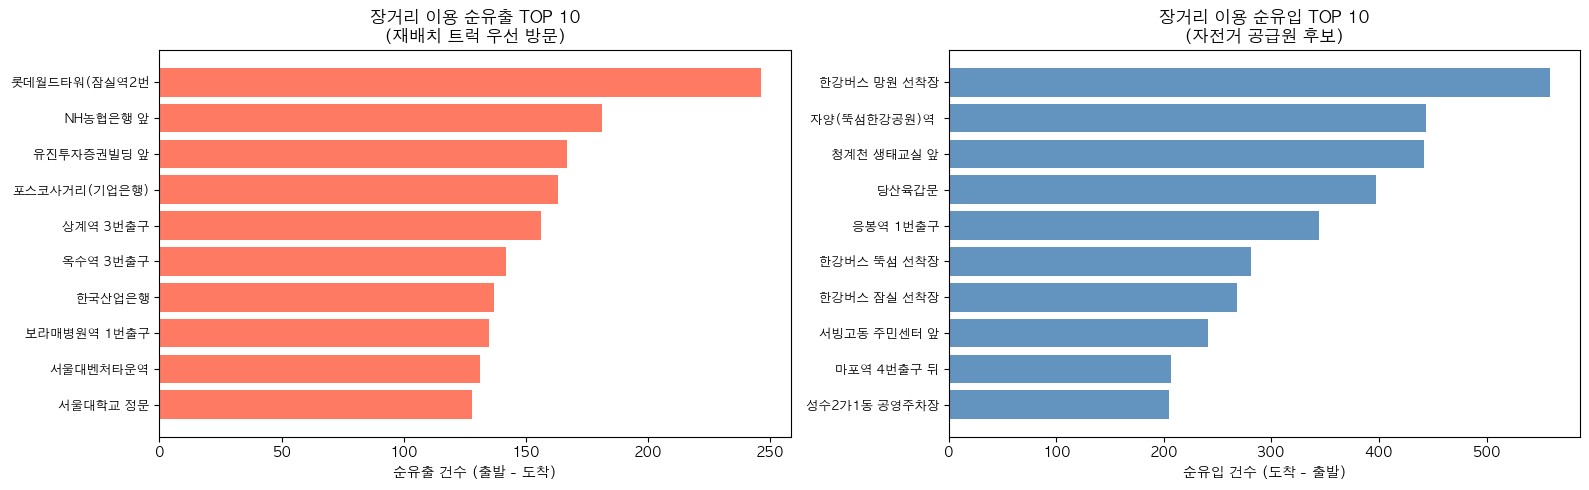


전체 장거리 이용 순유출 합계: 29,998건
순유출 양의 대여소: 1524개
순유입 양의 대여소: 1178개


In [16]:
long_trips = df_full2[df_full2["use_m"] > 10000].copy()

depart = long_trips.groupby("rent_stn_id").size().rename("출발_건수")
arrive = long_trips.groupby("rtrn_stn_id").size().rename("도착_건수")

flow_df = pd.concat([depart, arrive], axis=1).fillna(0).astype(int)
flow_df["순유출"] = flow_df["출발_건수"] - flow_df["도착_건수"]

stn_name = (df_full2[["rent_stn_id", "rent_stn_name"]]
            .drop_duplicates()
            .set_index("rent_stn_id")["rent_stn_name"])
flow_df = flow_df.join(stn_name, how="left")
flow_df["rent_stn_name"] = flow_df["rent_stn_name"].fillna(
    pd.Series(flow_df.index.astype(str), index=flow_df.index)
)

print(f"장거리 이용(10km+) 관련 대여소 수: {len(flow_df):,}개\n")

top_loss = flow_df.nlargest(10, "순유출")
top_gain = flow_df.nsmallest(10, "순유출")

print("=== 자전거 순유출 TOP 10 (재배치 트럭 우선 방문 대상) ===")
print(top_loss[["rent_stn_name", "출발_건수", "도착_건수", "순유출"]].to_string())

print("\n=== 자전거 순유입 TOP 10 (자전거 공급원 후보) ===")
print(top_gain[["rent_stn_name", "출발_건수", "도착_건수", "순유출"]].to_string())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

loss_labels = top_loss["rent_stn_name"].str[:12]
axes[0].barh(range(10), top_loss["순유출"].values[::-1], color="tomato", alpha=0.85)
axes[0].set_yticks(range(10))
axes[0].set_yticklabels(loss_labels.values[::-1], fontsize=9)
axes[0].set_title("장거리 이용 순유출 TOP 10\n(재배치 트럭 우선 방문)")
axes[0].set_xlabel("순유출 건수 (출발 - 도착)")

gain_labels = top_gain["rent_stn_name"].str[:12]
axes[1].barh(range(10), top_gain["순유출"].abs().values[::-1], color="steelblue", alpha=0.85)
axes[1].set_yticks(range(10))
axes[1].set_yticklabels(gain_labels.values[::-1], fontsize=9)
axes[1].set_title("장거리 이용 순유입 TOP 10\n(자전거 공급원 후보)")
axes[1].set_xlabel("순유입 건수 (도착 - 출발)")

plt.tight_layout()
plt.savefig("../reports/figures/long_trip_station_flow.png", dpi=150)
plt.show()

total_loss_vol = flow_df[flow_df["순유출"] > 0]["순유출"].sum()
total_gain_vol = flow_df[flow_df["순유출"] < 0]["순유출"].abs().sum()
print(f"\n전체 장거리 이용 순유출 합계: {total_loss_vol:,}건")
print(f"순유출 양의 대여소: {(flow_df['순유출'] > 0).sum()}개")
print(f"순유입 양의 대여소: {(flow_df['순유출'] < 0).sum()}개")

## 3. 대여소 시계열 이상치 (STL 분해)

📂 Loaded station_hourly_demand.parquet → shape: (3835657, 5)


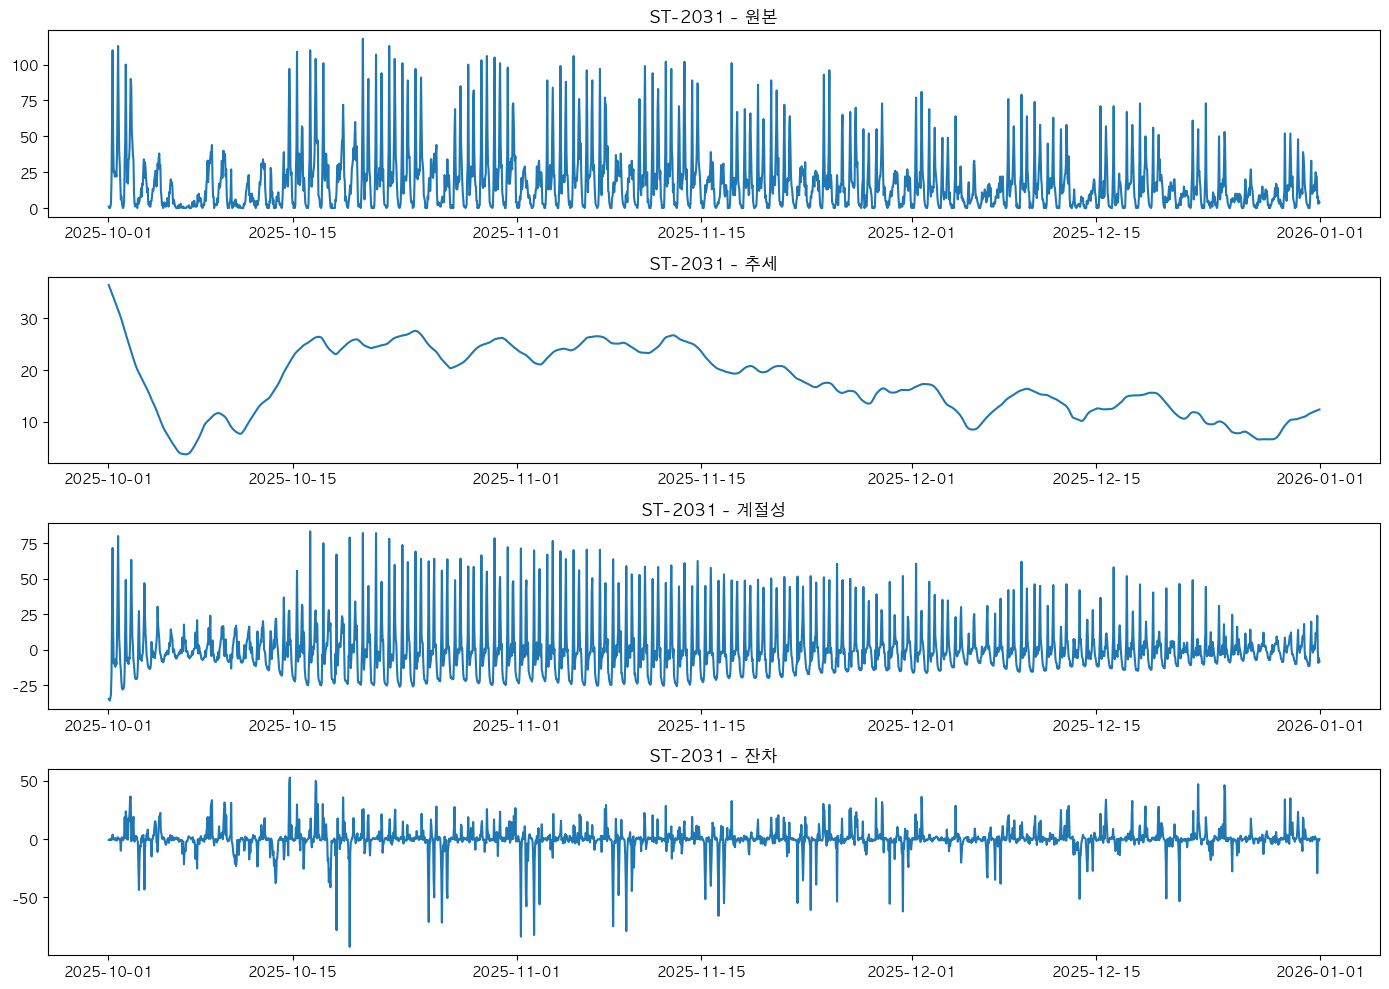

STL 잔차 이상치 시간: 58개
datetime_hour
2025-10-02 16:00:00    36.491711
2025-10-02 17:00:00    36.577414
2025-10-03 08:00:00   -43.716469
2025-10-03 18:00:00   -43.209658
2025-10-13 17:00:00   -37.763604
2025-10-13 18:00:00   -35.669196
2025-10-14 18:00:00    47.972680
2025-10-14 19:00:00    52.903825
2025-10-16 18:00:00    49.987336
2025-10-16 19:00:00    49.002803
2025-10-17 18:00:00   -36.974560
2025-10-17 21:00:00   -41.383094
2025-10-18 08:00:00   -78.200662
2025-10-18 20:00:00    35.864255
2025-10-19 08:00:00   -92.470960
2025-10-25 07:00:00   -36.642318
2025-10-25 08:00:00   -71.168959
2025-10-25 17:00:00   -35.582755
2025-10-25 18:00:00   -49.944277
2025-10-26 08:00:00   -71.762460
2025-10-26 17:00:00   -44.068827
2025-10-26 18:00:00   -50.603692
2025-11-01 08:00:00   -83.743277
2025-11-01 17:00:00   -46.394778
2025-11-01 18:00:00   -57.695336
2025-11-02 08:00:00   -82.377105
2025-11-02 18:00:00   -55.965758
2025-11-08 07:00:00   -35.539068
2025-11-08 08:00:00   -74.869069
2025-11-08

In [17]:
from statsmodels.tsa.seasonal import STL

hourly = load_processed("station_hourly_demand")

# 상위 대여소 1개 선택
top_stn = hourly.groupby("stn_id")["rent_count"].sum().idxmax()
stn_ts = hourly[hourly["stn_id"] == top_stn].set_index("datetime_hour")["rent_count"]
stn_ts = stn_ts.asfreq("h").fillna(0)

# STL 분해 (period=24: 하루 주기)
if len(stn_ts) >= 48:  # 최소 2일 이상의 데이터가 있어야 함
    stl = STL(stn_ts, period=24, robust=True)
    result = stl.fit()

    fig, axes = plt.subplots(4, 1, figsize=(14, 10))
    for ax, data, title in zip(axes,
                                [stn_ts, result.trend, result.seasonal, result.resid],
                                ["원본", "추세", "계절성", "잔차"]):
        ax.plot(data)
        ax.set_title(f"{top_stn} - {title}")
    plt.tight_layout()
    plt.savefig("../reports/figures/stl_decomposition.png", dpi=150)
    plt.show()

    # 잔차 기반 이상치 탐지
    resid_std = result.resid.std()
    anomaly_mask = np.abs(result.resid) > 3 * resid_std
    print(f"STL 잔차 이상치 시간: {anomaly_mask.sum()}개")
    print(result.resid[anomaly_mask])
else:
    print("데이터가 부족하여 STL 분해를 건너뜁니다.")

## 4. 이상치 점수 저장

In [18]:
# 이상치 점수를 원본 데이터에 조인 (Isolation Forest)
df_out = df.copy()
iso_scores = pd.Series(df_sample["iso_score"].values, index=df_sample.index, name="iso_anomaly_score")
df_out = df_out.join(iso_scores, how="left")
df_out["iso_anomaly_score"] = df_out["iso_anomaly_score"].fillna(0)

save_processed(df_out, "trip_anomaly_scores")

# 모델 저장
model_dir = Path("../models/anomaly")
model_dir.mkdir(parents=True, exist_ok=True)
joblib.dump(iso_forest, model_dir / "isolation_forest.pkl")
joblib.dump(scaler, model_dir / "scaler.pkl")
print("\u2705 이상치 탐지 모델 저장 완료")

💾 Saved → /Users/hayoung/seoul-bike-ml/data/processed/trip_anomaly_scores.parquet  (332.1 MB)
✅ 이상치 탐지 모델 저장 완료


## 시각화: 일별 대여량 및 STL 이상치 탐지 시점

대여소: ST-2031 / 일별 데이터: 92일 / STL 이상: 31개 날짜
날짜 범위: 2025-10-01 ~ 2025-12-31


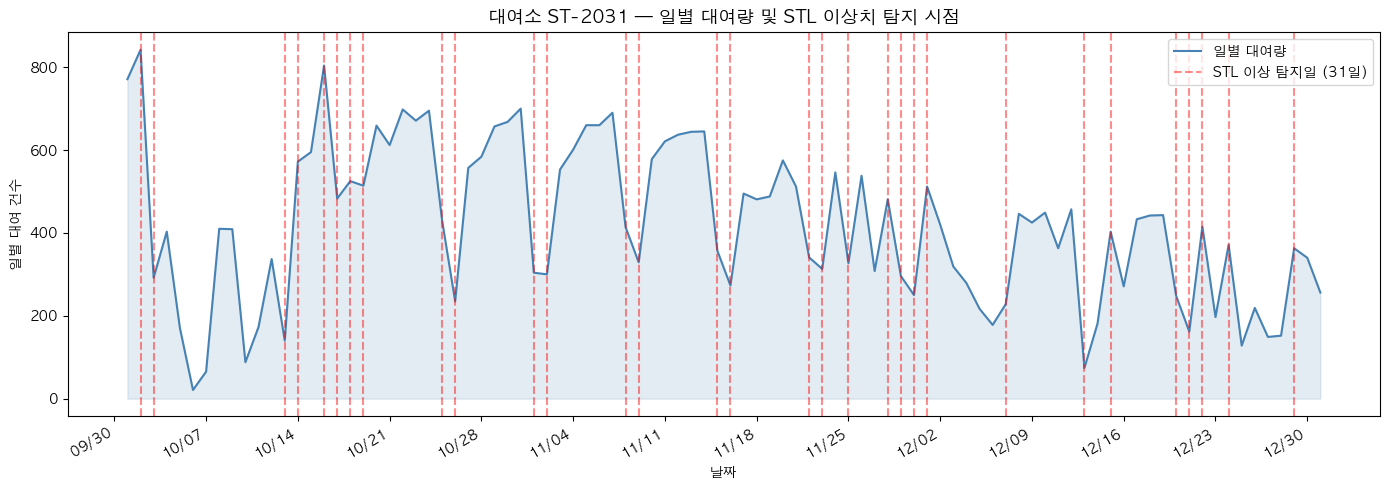

In [19]:
import matplotlib.dates as mdates

# top_stn 재확인 (현재 스코프 기준)
top_stn_vis = hourly.groupby("stn_id")["rent_count"].sum().idxmax()

# top_stn 일별 집계
_h = hourly[hourly["stn_id"] == top_stn_vis].copy()
_h["datetime_hour"] = pd.to_datetime(_h["datetime_hour"])
_h = _h.set_index("datetime_hour").sort_index()["rent_count"]
daily_top = _h.resample("D").sum()

# stl_all에서 해당 스테이션의 이상 날짜 추출
anom_dates = pd.to_datetime(
    stl_all[stl_all["stn_id"] == top_stn_vis]["datetime"]
).dt.normalize().unique()

print(f"대여소: {top_stn_vis} / 일별 데이터: {len(daily_top)}일 / STL 이상: {len(anom_dates)}개 날짜")
print(f"날짜 범위: {daily_top.index.min().date()} ~ {daily_top.index.max().date()}")

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(daily_top.index, daily_top.values, alpha=0.15, color="steelblue")
ax.plot(daily_top.index, daily_top.values, color="steelblue", linewidth=1.5, label="일별 대여량")

for i, d in enumerate(sorted(anom_dates)):
    label = f"STL 이상 탐지일 ({len(anom_dates)}일)" if i == 0 else None
    ax.axvline(x=d, color="red", alpha=0.45, linewidth=1.5, linestyle="--", label=label)

ax.xaxis.set_major_formatter(mdates.DateFormatter("%m/%d"))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=7))
plt.xticks(rotation=30, ha="right")
ax.set_title(f"대여소 {top_stn_vis} — 일별 대여량 및 STL 이상치 탐지 시점", fontsize=13)
ax.set_xlabel("날짜")
ax.set_ylabel("일별 대여 건수")
ax.legend()
plt.tight_layout()
plt.savefig("../reports/figures/stl_daily_anomaly.png", dpi=150, bbox_inches="tight")
plt.show()

---

## 운영 대응 종합표

본 분석에서 탐지된 이상 유형별 건수, 탐지 방법, 운영 액션을 종합한다.

In [20]:
import pandas as pd

# ── 각 섹션에서 산출된 수치를 종합 ──────────────────────────────────────────
# (노트북 전체 실행 시 각 변수가 정의되어 있음)

summary_data = {
    "이상 유형": [
        "GPS 오류 (속도 35km/h 초과)",
        "방치 자전거 (룰 기반)",
        "방치 자전거 (IF 추가 탐지)",
        "수요 급변 이상 (STL, 50개 스테이션)",
        "스테이션 자전거 순유출",
    ],
    "탐지 방법": [
        "Rule-based",
        "Rule-based (use_min_calc > 360 & use_m < 500)",
        "Isolation Forest (단거리 영역 한정, contamination=0.005)",
        "STL 분해 (3σ 임계값)",
        "출발·도착 카운트 차이 분석",
    ],
    "탐지 건수": [
        "315건 (전체의 0.004%)",
        "248건 (전체의 0.003%)",
        "단거리 영역 샘플의 0.5% (별도 집계)",
        f"{len(stl_all)}건 / {len(top50_stns)}개 스테이션",
        "순유출 1위: 롯데월드타워 +246건",
    ],
    "운영 액션": [
        "데이터 정제 파이프라인 — 분석 전 자동 제거",
        "현장 회수 알림 — 360분 초과 시 담당자 통보",
        "룰 미포착 경계 케이스 추가 검토",
        "수요 급증 전날 재배치 / 급감 시 배치 생략",
        "주간 재배치 트럭 루트 — 유출 상위 스테이션 우선",
    ],
    "담당 부서": [
        "데이터팀",
        "현장 운영팀",
        "현장 운영팀",
        "운영 기획팀",
        "물류·재배치팀",
    ],
}

df_summary = pd.DataFrame(summary_data)
print("=" * 80)
print("따릉이 이상치 탐지 — 운영 대응 종합표")
print("=" * 80)
print(df_summary.to_string(index=False))
print("=" * 80)

# 스타일 테이블로 출력 (Jupyter에서 렌더링)
df_summary.style.set_caption("따릉이 이상치 탐지 운영 대응 종합표") \
    .set_table_styles([
        {"selector": "caption", "props": [("font-size", "14px"), ("font-weight", "bold")]},
        {"selector": "th", "props": [("background-color", "#4472C4"), ("color", "white"), ("text-align", "center")]},
        {"selector": "td", "props": [("text-align", "left"), ("padding", "6px")]},
        {"selector": "tr:nth-child(even)", "props": [("background-color", "#f2f2f2")]},
    ])

따릉이 이상치 탐지 — 운영 대응 종합표
                   이상 유형                                             탐지 방법                   탐지 건수                        운영 액션   담당 부서
   GPS 오류 (속도 35km/h 초과)                                        Rule-based       315건 (전체의 0.004%)    데이터 정제 파이프라인 — 분석 전 자동 제거    데이터팀
           방치 자전거 (룰 기반)     Rule-based (use_min_calc > 360 & use_m < 500)       248건 (전체의 0.003%)  현장 회수 알림 — 360분 초과 시 담당자 통보  현장 운영팀
       방치 자전거 (IF 추가 탐지) Isolation Forest (단거리 영역 한정, contamination=0.005) 단거리 영역 샘플의 0.5% (별도 집계)           룰 미포착 경계 케이스 추가 검토  현장 운영팀
수요 급변 이상 (STL, 50개 스테이션)                                   STL 분해 (3σ 임계값)        2776건 / 50개 스테이션    수요 급증 전날 재배치 / 급감 시 배치 생략  운영 기획팀
            스테이션 자전거 순유출                                   출발·도착 카운트 차이 분석    순유출 1위: 롯데월드타워 +246건 주간 재배치 트럭 루트 — 유출 상위 스테이션 우선 물류·재배치팀


,이상 유형,탐지 방법,탐지 건수,운영 액션,담당 부서
0,GPS 오류 (속도 35km/h 초과),Rule-based,315건 (전체의 0.004%),데이터 정제 파이프라인 — 분석 전 자동 제거,데이터팀
1,방치 자전거 (룰 기반),Rule-based (use_min_calc > 360 & use_m < 500),248건 (전체의 0.003%),현장 회수 알림 — 360분 초과 시 담당자 통보,현장 운영팀
2,방치 자전거 (IF 추가 탐지),"Isolation Forest (단거리 영역 한정, contamination=0.005)",단거리 영역 샘플의 0.5% (별도 집계),룰 미포착 경계 케이스 추가 검토,현장 운영팀
3,"수요 급변 이상 (STL, 50개 스테이션)",STL 분해 (3σ 임계값),2776건 / 50개 스테이션,수요 급증 전날 재배치 / 급감 시 배치 생략,운영 기획팀
4,스테이션 자전거 순유출,출발·도착 카운트 차이 분석,순유출 1위: 롯데월드타워 +246건,주간 재배치 트럭 루트 — 유출 상위 스테이션 우선,물류·재배치팀
